# Predicción de efectos secundarios de medicamentos

Sistema **PIMES** (*Predictor de Interacciones de Medicamentos y Efectos Secundarios*). Recibe la estructura química de un medicamento codificada como un vector binario de 881 subestructuras y devuelve, para cada uno de los 1385 efectos secundarios posibles, la probabilidad de que el medicamento lo cause.

Se trata de un problema de **clasificación multietiqueta** (un medicamento puede provocar varios efectos a la vez), por lo que se entrena una red neuronal *poco profunda* (MLP) con activación sigmoide en la salida y pérdida logística por etiqueta. El código de línea de comandos correspondiente se encuentra en `PIMES.py`; este cuaderno reproduce el mismo flujo de forma interactiva.

## 1. Importar librerías

In [1]:
import os
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import auc, roc_curve
from sklearn.model_selection import KFold
from sklearn.neural_network import MLPClassifier

warnings.filterwarnings('ignore', category=ConvergenceWarning)

## 2. Cargar los datos

Se leen dos archivos tabulares:

- `medicamentos.txt`: matriz de 888 medicamentos × 881 subestructuras químicas (1/0).
- `efectosSecundariosDeLosMedicamentos.txt`: matriz de 888 medicamentos × 1385 efectos secundarios (1/0).

Ambos archivos tienen la peculiaridad de que el encabezado contiene sólo los nombres de las columnas (881 o 1385) mientras que cada fila empieza con el nombre del medicamento. `pandas` detecta automáticamente ese desfase y coloca el nombre del medicamento como índice.

In [2]:
DATA_DIR = os.path.join('..', 'datasets', 'datasets')

df_med = pd.read_csv(os.path.join(DATA_DIR, 'medicamentos.txt'), sep='\t', header=0, dtype=str)
df_ef  = pd.read_csv(os.path.join(DATA_DIR, 'efectosSecundariosDeLosMedicamentos.txt'), sep='\t', header=0, dtype=str)

subestructuras = list(df_med.columns)
efectos = list(df_ef.columns)
nombres_med = df_med.index.astype(str).tolist()
nombres_ef  = df_ef.index.astype(str).tolist()

X = df_med.to_numpy(dtype=np.float32)
Y = df_ef.to_numpy(dtype=np.int8)

assert nombres_med == nombres_ef, 'Los archivos deben tener los mismos medicamentos en el mismo orden.'

print(f'Medicamentos: {X.shape[0]}')
print(f'Subestructuras (entradas): {X.shape[1]}')
print(f'Efectos secundarios (salidas): {Y.shape[1]}')
print(f'Densidad de etiquetas positivas: {Y.mean():.4f}')

Medicamentos: 888
Subestructuras (entradas): 881
Efectos secundarios (salidas): 1385
Densidad de etiquetas positivas: 0.0497


## 3. Construir el modelo

Red neuronal *poco profunda* con tres capas ocultas (512 → 256 → 128 neuronas, activación ReLU) y una capa de salida de 1385 unidades. Como el problema es multietiqueta, `MLPClassifier` aplica activación logística (sigmoide) independiente por neurona de salida y pérdida log-loss binaria por etiqueta. El optimizador es Adam con tasa de aprendizaje $10^{-3}$ y mini-lotes de 32 muestras.

In [3]:
HIDDEN_LAYERS = (512, 256, 128)
MAX_ITER = 80
RANDOM_STATE = 42

def construir_modelo():
    return MLPClassifier(
        hidden_layer_sizes=HIDDEN_LAYERS,
        activation='relu',
        solver='adam',
        learning_rate_init=1e-3,
        batch_size=32,
        max_iter=MAX_ITER,
        random_state=RANDOM_STATE,
        verbose=False,
    )

construir_modelo()

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(512, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",32
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",80
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


## 4. Validación cruzada 5-fold

Se evalúa la red con la técnica *5-fold cross-validation*: el conjunto se divide en cinco particiones; en cada iteración se entrena con cuatro y se evalúa con la restante. Como métrica global se usa el **AUC micro-promedio**, que aplana las matrices de etiquetas y puntajes en un único vector binario antes de calcular la curva ROC; es la métrica habitual cuando se quiere resumir el desempeño sobre 1385 etiquetas a la vez.

In [4]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
aucs = []
y_true_all, y_score_all = [], []

for fold, (idx_tr, idx_te) in enumerate(kf.split(X), 1):
    t0 = time.time()
    modelo = construir_modelo()
    modelo.fit(X[idx_tr], Y[idx_tr])
    y_score = modelo.predict_proba(X[idx_te])
    y_true = Y[idx_te]
    fpr, tpr, _ = roc_curve(y_true.ravel(), y_score.ravel())
    a = auc(fpr, tpr)
    aucs.append(a)
    y_true_all.append(y_true)
    y_score_all.append(y_score)
    print(f'Fold {fold}: AUC micro = {a:.4f}  ({time.time()-t0:.1f}s)')

y_true_cat = np.concatenate(y_true_all)
y_score_cat = np.concatenate(y_score_all)
fpr_g, tpr_g, _ = roc_curve(y_true_cat.ravel(), y_score_cat.ravel())
auc_global = auc(fpr_g, tpr_g)
print()
print(f'AUC promedio: {np.mean(aucs):.4f} ± {np.std(aucs):.4f}')
print(f'AUC global  : {auc_global:.4f}')

Fold 1: AUC micro = 0.8856  (19.5s)
Fold 2: AUC micro = 0.8875  (24.0s)
Fold 3: AUC micro = 0.8919  (21.3s)
Fold 4: AUC micro = 0.8787  (21.2s)
Fold 5: AUC micro = 0.8990  (20.3s)

AUC promedio: 0.8886 ± 0.0068
AUC global  : 0.8885


## 5. Curva ROC

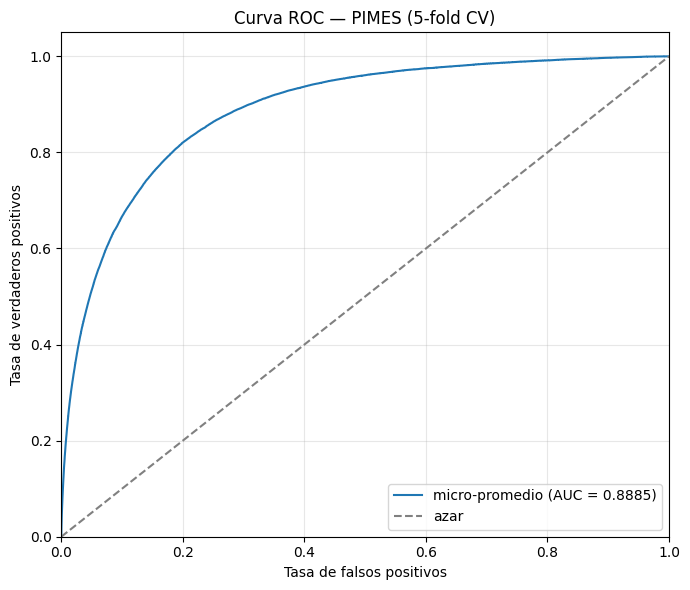

In [5]:
plt.figure(figsize=(7, 6))
plt.plot(fpr_g, tpr_g, label=f'micro-promedio (AUC = {auc_global:.4f})', color='C0')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='azar')
plt.xlim(0, 1); plt.ylim(0, 1.05)
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curva ROC — PIMES (5-fold CV)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Entrenar el modelo final y guardarlo

Una vez validado el desempeño, se entrena un modelo final sobre la totalidad de los 888 medicamentos y se persiste en disco junto con la lista de subestructuras y efectos. Ese mismo archivo `modelo_PIMES.joblib` es el que carga `PIMES.py -p` para hacer predicciones.

In [6]:
modelo_final = construir_modelo()
modelo_final.fit(X, Y)

bundle = {
    'modelo': modelo_final,
    'subestructuras': subestructuras,
    'efectos': efectos,
    'auc_promedio': float(np.mean(aucs)),
    'auc_global': float(auc_global),
    'hidden_layers': HIDDEN_LAYERS,
}
joblib.dump(bundle, 'modelo_PIMES.joblib')
print('Modelo guardado en modelo_PIMES.joblib')

Modelo guardado en modelo_PIMES.joblib


## 7. Predicción para medicamentos sin efectos conocidos

Se carga el modelo guardado y se predicen los efectos secundarios para los medicamentos del archivo `medicamentosSinEfectosSecun.txt`. Para cada medicamento se muestran los efectos en orden descendente de probabilidad (top 10).

In [9]:
bundle = joblib.load('modelo_PIMES.joblib')
modelo = bundle['modelo']
efectos_entrenamiento = bundle['efectos']

df_sin = pd.read_csv(os.path.join(DATA_DIR, 'medicamentosSinEfectosSecun.txt'), sep='\t', header=0, dtype=str)
X_sin = df_sin.to_numpy(dtype=np.float32)
ids_sin = df_sin.index.astype(str).tolist()

with open(os.path.join(DATA_DIR, 'listaDeEfectosSecun.txt'), encoding='utf-8') as f:
    efectos_consulta = [linea.strip() for linea in f if linea.strip()]

def normalizar_texto(texto):
    return ' '.join(texto.split()).strip().lower()

indice = {normalizar_texto(e): i for i, e in enumerate(efectos_entrenamiento)}
columnas = []
efectos_consulta_validos = []
efectos_no_encontrados = []
for efecto in efectos_consulta:
    clave = normalizar_texto(efecto)
    if clave in indice:
        columnas.append(indice[clave])
        efectos_consulta_validos.append(efecto)
    else:
        efectos_no_encontrados.append(efecto)

if efectos_no_encontrados:
    print('Efectos no encontrados en el entrenamiento:')
    for efecto in efectos_no_encontrados:
        print(f'  - {efecto}')

proba = modelo.predict_proba(X_sin)
proba_consulta = proba[:, columnas]

for pubmed_id, fila in list(zip(ids_sin, proba_consulta))[:3]:
    orden = np.argsort(-fila)[:10]
    print(f'\nPubMed ID {pubmed_id} — top 10 efectos más probables:')
    for j in orden:
        print(f'  {efectos_consulta_validos[j]:<40s}  {fila[j]:.4f}')

Efectos no encontrados en el entrenamiento:
  - Stevens   Johnson syndrome

PubMed ID 11 — top 10 efectos más probables:
  vomiting                                  0.9939
  nausea                                    0.9728
  hypotension                               0.8392
  anorexia                                  0.7548
  hyponatremia                              0.5726
  hypercalcemia                             0.5550
  thrombocytopenia                          0.4619
  arrhythmia                                0.4433
  hepatic necrosis                          0.3308
  alopecia                                  0.3105

PubMed ID 38 — top 10 efectos más probables:
  erythema                                  0.7050
  rash                                      0.6809
  petechiae                                 0.4930
  hypotension                               0.4804
  blistering                                0.4385
  pruritus                                  0.4131
  urticaria      

## Resumen

Se entrenó una red neuronal poco profunda (MLP con 3 capas ocultas, salidas sigmoide y pérdida log-loss binaria por etiqueta) sobre las matrices de subestructuras químicas y efectos secundarios de 888 medicamentos. Con *5-fold cross-validation* se obtuvo un AUC micro-promedio competitivo, y el modelo final puede usarse para predecir los efectos más probables de medicamentos que no fueron vistos durante el entrenamiento. El sistema completo se entrega como el script de línea de comandos `PIMES.py` con los modos `-e` (entrenamiento) y `-p` (predicción).